### Step 1 - Paths

In [10]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
OUT_DIR = BASE_DIR / "analysis" / "phase4_weighted_eval"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VAL_MANIFEST = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"

TUNED_CKPT = CKPT_DIR / "lr5e4_base24_bs2_cont_to_50_best.pt"
WEIGHTED_CKPT = CKPT_DIR / "phase4_weighted_flow_lr5e4_base24_bs2_T0p10_best.pt"

print("VAL_MANIFEST exists:", VAL_MANIFEST.exists())
print("TUNED_CKPT exists:", TUNED_CKPT.exists())
print("WEIGHTED_CKPT exists:", WEIGHTED_CKPT.exists())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
VAL_MANIFEST exists: True
TUNED_CKPT exists: True
WEIGHTED_CKPT exists: True
device: cuda


### Step 2 — Reuse verified definitions

In [21]:
# Step 2: Paste the following verified definitions here from working notebook:
# - CubePair3DDataset
# - ConditionalUNetFlow3D
# - euler_sample_flow_3d
# - compute_flow_matching_loss
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)



class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        # xt, x0: (B,1,D,H,W)
        # t:      (B,1,1,1,1)
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])  # (B,1,D,H,W)
        inp = torch.cat([xt, x0, t_map], dim=1)  # (B,3,D,H,W)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b  = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)  # predicted velocity


@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    """
    x0: (B,1,D,H,W)
    """
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z


def sample_t_like(x):
    return torch.rand((x.shape[0], 1, 1, 1, 1), device=x.device)


def compute_flow_matching_loss(model, x0, x1):
    t = sample_t_like(x0)
    z_t = (1.0 - t) * x0 + t * x1
    v_target = x1 - x0
    v_pred = model(z_t, x0, t)
    return F.mse_loss(v_pred, v_target)

In [32]:
# Step 5: Helper functions

@torch.no_grad()
def get_flow_prediction(model, dataset, idx, device, n_steps=30):
    x0, x1 = dataset[idx]

    x0_t = x0.unsqueeze(0).to(device)
    pred = euler_sample_flow_3d(model, x0_t, n_steps=n_steps).cpu().squeeze().numpy()

    ct_vol = x0.squeeze().numpy()
    gt_vol = x1.squeeze().numpy()
    return ct_vol, gt_vol, pred


def find_best_dose_slice_index(volume):
    """
    Find the slice index with the largest total dose intensity.
    """
    slice_sums = volume.reshape(volume.shape[0], -1).sum(axis=1)
    return int(np.argmax(slice_sums))


def find_peak_xy(volume, slice_idx):
    """
    Find the (y, x) location of the maximum value on a given slice.
    """
    slice_2d = volume[slice_idx]
    peak_idx = np.unravel_index(np.argmax(slice_2d), slice_2d.shape)
    return peak_idx  # (y, x)


# Step 8: Percentage error helper functions

def compute_profile_percentage_error(
    gt_curve,
    pred_curve,
    mode="relative_to_curve_max",
    threshold=0.01,
    eps=1e-8,
    return_mask=False
):
    """
    中文：
    只在“relevant region”计算 percentage error。
    对 near-zero tail 区域，不再强行设成 0，而是设成 NaN。

    参数：
    - mode="relative_to_curve_max":
        用 threshold * max(gt_curve) 作为 relevant threshold
        例如 threshold=0.01 表示只在 gt >= 1% * curve max 的位置计算 percentage error
    - mode="absolute":
        用固定绝对阈值 threshold
    - eps:
        数值保护下限
    - return_mask:
        是否同时返回 valid mask

    English:
    Compute percentage error only in the relevant region.
    Near-zero tail regions are set to NaN instead of being forced to zero.
    """
    gt_curve = np.asarray(gt_curve, dtype=np.float64)
    pred_curve = np.asarray(pred_curve, dtype=np.float64)

    if mode == "relative_to_curve_max":
        ref = float(np.max(gt_curve))
        relevant_threshold = max(threshold * ref, eps)
    elif mode == "absolute":
        relevant_threshold = max(float(threshold), eps)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    valid_mask = gt_curve >= relevant_threshold

    pct_err = np.full_like(gt_curve, np.nan, dtype=np.float64)
    pct_err[valid_mask] = (
        100.0 * np.abs(pred_curve[valid_mask] - gt_curve[valid_mask]) /
        np.maximum(gt_curve[valid_mask], eps)
    )

    if return_mask:
        return pct_err, valid_mask, relevant_threshold
    return pct_err


def summarize_profile_percentage_error(gt_profile, pred_profile, threshold_ratio=0.01, eps=1e-8):
    pct_error, mask = compute_profile_percentage_error(gt_profile, pred_profile, threshold_ratio, eps)

    if np.any(mask):
        mean_pct = float(np.mean(pct_error[mask]))
        max_pct = float(np.max(pct_error[mask]))
    else:
        mean_pct = np.nan
        max_pct = np.nan

    return {
        "mean_pct_error": mean_pct,
        "max_pct_error": max_pct,
        "pct_error_curve": pct_error,
        "mask": mask,
    }


# Step 9: Cross-sectional figure with matched scales

def save_cross_section_with_matched_scales(ct_vol, gt_vol, pred_vol, slice_idx, save_path, title_prefix=""):
    diff_vol = np.abs(pred_vol - gt_vol)

    dose_vmax = max(float(gt_vol[slice_idx].max()), float(pred_vol[slice_idx].max()))
    diff_vmax = float(np.percentile(diff_vol[slice_idx], 99))
    diff_vmax = max(diff_vmax, 1e-8)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    im0 = axes[0].imshow(ct_vol[slice_idx], cmap="gray")
    axes[0].set_title(f"{title_prefix} Input CT")
    axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(gt_vol[slice_idx], cmap="hot", vmin=0.0, vmax=dose_vmax)
    axes[1].set_title(f"{title_prefix} Ground Truth")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(pred_vol[slice_idx], cmap="hot", vmin=0.0, vmax=dose_vmax)
    axes[2].set_title(f"{title_prefix} Prediction")
    axes[2].axis("off")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    im3 = axes[3].imshow(diff_vol[slice_idx], cmap="hot", vmin=0.0, vmax=diff_vmax)
    axes[3].set_title(f"{title_prefix} Abs Difference")
    axes[3].axis("off")
    fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)


# Step 10: Profile plots with percentage error

def plot_profile_with_percentage_error(
    gt_curve,
    pred_curve,
    title,
    xlabel,
    save_path,
    pct_mode="relative_to_curve_max",
    pct_threshold=0.01,
    eps=1e-8
):
    abs_diff = np.abs(gt_curve - pred_curve)

    pct_err, valid_mask, relevant_threshold = compute_profile_percentage_error(
        gt_curve,
        pred_curve,
        mode=pct_mode,
        threshold=pct_threshold,
        eps=eps,
        return_mask=True
    )

    fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

    # Top: dose / prediction / abs diff
    axes[0].plot(gt_curve, label="Ground Truth")
    axes[0].plot(pred_curve, label="Prediction")
    axes[0].plot(abs_diff, label="Abs Difference")
    axes[0].set_title(title)
    axes[0].set_ylabel("Dose")
    axes[0].legend()

    # Bottom: percentage error (only relevant region)
    axes[1].plot(pct_err, label="Percentage Error (%)")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel("Percentage Error (%)")
    axes[1].legend()

    if np.any(valid_mask):
        mean_pct = float(np.nanmean(pct_err))
        max_pct = float(np.nanmax(pct_err))
        valid_count = int(valid_mask.sum())
        total_count = int(len(valid_mask))
        axes[1].set_title(
            f"Mean % error = {mean_pct:.3f}, Max % error = {max_pct:.3f} "
            f"(valid {valid_count}/{total_count}, thr={relevant_threshold:.4g})"
        )
    else:
        axes[1].set_title("Percentage Error: no valid region above threshold")

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close()



# Step 11: Analyze one case

# Step 11: Analyze one case (updated)

def analyze_one_case(dataset, sample_idx, model, device, out_dir, prefix):
    ct_vol, gt_vol, pred_vol = get_flow_prediction(model, dataset, sample_idx, device, n_steps=30)

    slice_idx = find_best_dose_slice_index(gt_vol)
    peak_y, peak_x = find_peak_xy(gt_vol, slice_idx)

    save_cross_section_with_matched_scales(
        ct_vol,
        gt_vol,
        pred_vol,
        slice_idx,
        out_dir / f"{prefix}_cross_section.png",
        title_prefix=prefix.replace("_", " ").title()
    )

    gt_along = gt_vol[slice_idx, peak_y, :]
    pred_along = pred_vol[slice_idx, peak_y, :]
    along_stats = plot_profile_with_percentage_error(
        gt_along,
        pred_along,
        out_dir / f"{prefix}_along_beam_profile_with_pct_error.png",
        title_main=f"{prefix.replace('_', ' ').title()}: Along-Beam Profile",
        xlabel="x index (approx. beam direction)",
        pct_mode="relative_to_curve_max",
        pct_threshold=0.01
    )

    gt_perp = gt_vol[slice_idx, :, peak_x]
    pred_perp = pred_vol[slice_idx, :, peak_x]
    perp_stats = plot_profile_with_percentage_error(
        gt_perp,
        pred_perp,
        out_dir / f"{prefix}_perpendicular_profile_with_pct_error.png",
        title_main=f"{prefix.replace('_', ' ').title()}: Perpendicular Profile",
        xlabel="y index (perpendicular to beam)",
        pct_mode="relative_to_curve_max",
        pct_threshold=0.01
    )

    mse = float(np.mean((pred_vol - gt_vol) ** 2))
    mae = float(np.mean(np.abs(pred_vol - gt_vol)))
    rel_err_pct = float(100.0 * np.sum(np.abs(pred_vol - gt_vol)) / (np.sum(np.abs(gt_vol)) + EPS))

    result = {
        "sample_idx": sample_idx,
        "best_slice": slice_idx,
        "peak_y": peak_y,
        "peak_x": peak_x,
        "gt_max": float(gt_vol.max()),
        "mse": mse,
        "mae": mae,
        "relative_error_pct": rel_err_pct,

        "along_mean_pct_error": along_stats["mean_pct_error"],
        "along_max_pct_error": along_stats["max_pct_error"],
        "along_valid_count": along_stats["valid_count"],
        "along_total_count": along_stats["total_count"],
        "along_relevant_threshold": along_stats["relevant_threshold"],

        "perp_mean_pct_error": perp_stats["mean_pct_error"],
        "perp_max_pct_error": perp_stats["max_pct_error"],
        "perp_valid_count": perp_stats["valid_count"],
        "perp_total_count": perp_stats["total_count"],
        "perp_relevant_threshold": perp_stats["relevant_threshold"],
    }

    return result




### Step 4 - New weighted evaluation helper

In [33]:
EPS = 1e-8
DOSE_SCALE = 1000.0

THRESHOLD = 0.10
THRESHOLD_MODE = "absolute"   # "absolute" or "relative_to_case_max"

def get_case_threshold(gt_vol, threshold=0.10, mode="absolute"):
    """
    gt_vol: 3D numpy array, already scaled dose
    """
    if mode == "absolute":
        T = float(threshold)
    elif mode == "relative_to_case_max":
        T = float(threshold) * float(gt_vol.max())
    else:
        raise ValueError(f"Unknown threshold mode: {mode}")
    return max(T, 1e-8)

def compute_weighted_eval_metrics(gt_vol, pred_vol, threshold=0.10, mode="absolute"):
    """
    Define the high-dose region from the ground truth and compute:
    - overall metrics
    - high-dose metrics
    - outside metrics
    - peak-core / peak-shoulder metrics
    """
    T = get_case_threshold(gt_vol, threshold=threshold, mode=mode)

    abs_err = np.abs(pred_vol - gt_vol)
    sq_err = (pred_vol - gt_vol) ** 2

    # weighting map
    weight = np.maximum(T, gt_vol) / T
    weighted_mse = float(np.mean(weight * sq_err))

    # masks
    high_mask = gt_vol >= T
    outside_mask = gt_vol < T

    gt_max = float(gt_vol.max())
    peak_core_mask = gt_vol >= (0.8 * gt_max)
    peak_shoulder_mask = (gt_vol >= 0.3 * gt_max) & (gt_vol < 0.8 * gt_max)

    def safe_mean(arr):
        return float(np.mean(arr)) if arr.size > 0 else np.nan

    def safe_max(arr):
        return float(np.max(arr)) if arr.size > 0 else np.nan

    def safe_p95(arr):
        return float(np.percentile(arr, 95)) if arr.size > 0 else np.nan

    result = {
        "overall_mse": float(np.mean(sq_err)),
        "overall_mae": float(np.mean(abs_err)),
        "weighted_mse": weighted_mse,

        "high_mse": safe_mean(sq_err[high_mask]),
        "high_mae": safe_mean(abs_err[high_mask]),

        "outside_mse": safe_mean(sq_err[outside_mask]),
        "outside_mae": safe_mean(abs_err[outside_mask]),
        "outside_max_abs_error": safe_max(abs_err[outside_mask]),
        "outside_p95_abs_error": safe_p95(abs_err[outside_mask]),

        "peak_core_mae": safe_mean(abs_err[peak_core_mask]),
        "peak_shoulder_mae": safe_mean(abs_err[peak_shoulder_mask]),

        "threshold_used": T,
        "num_high_voxels": int(high_mask.sum()),
        "num_outside_voxels": int(outside_mask.sum()),
    }
    return result

### Step 5 — Load datasets and two models

In [34]:
val_dataset_3d = CubePair3DDataset(VAL_MANIFEST, dose_scale=DOSE_SCALE)

tuned_ckpt = torch.load(TUNED_CKPT, map_location="cpu")
weighted_ckpt = torch.load(WEIGHTED_CKPT, map_location="cpu")

tuned_model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=24).to(device)
weighted_model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=24).to(device)

tuned_model.load_state_dict(tuned_ckpt["model_state_dict"])
weighted_model.load_state_dict(weighted_ckpt["model_state_dict"])

tuned_model.eval()
weighted_model.eval()

print("Validation samples:", len(val_dataset_3d))
print("Models loaded successfully.")

Validation samples: 500
Models loaded successfully.


### Step 6 — Full comparison table

In [35]:
all_rows = []

for idx in range(len(val_dataset_3d)):
    # tuned prediction
    ct_vol, gt_vol, tuned_pred = get_flow_prediction(
        tuned_model, val_dataset_3d, idx, device, n_steps=30
    )
    tuned_metrics = compute_weighted_eval_metrics(
        gt_vol, tuned_pred,
        threshold=THRESHOLD,
        mode=THRESHOLD_MODE
    )
    row_tuned = {
        "model": "tuned",
        "sample_idx": idx,
        **tuned_metrics
    }
    all_rows.append(row_tuned)

    # weighted prediction
    _, _, weighted_pred = get_flow_prediction(
        weighted_model, val_dataset_3d, idx, device, n_steps=30
    )
    weighted_metrics = compute_weighted_eval_metrics(
        gt_vol, weighted_pred,
        threshold=THRESHOLD,
        mode=THRESHOLD_MODE
    )
    row_weighted = {
        "model": "weighted",
        "sample_idx": idx,
        **weighted_metrics
    }
    all_rows.append(row_weighted)

comparison_df = pd.DataFrame(all_rows)

comparison_csv = OUT_DIR / "phase4_weighted_vs_tuned_casewise_metrics.csv"
comparison_df.to_csv(comparison_csv, index=False)

print("Saved:", comparison_csv)
display(comparison_df.head())

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase4_weighted_eval/phase4_weighted_vs_tuned_casewise_metrics.csv


,model,sample_idx,overall_mse,overall_mae,weighted_mse,high_mse,high_mae,outside_mse,outside_mae,outside_max_abs_error,outside_p95_abs_error,peak_core_mae,peak_shoulder_mae,threshold_used,num_high_voxels,num_outside_voxels
0,tuned,0,0.000015,0.002473,0.000064,0.000051,0.005007,0.000009,0.002039,0.033027,0.005827,0.116217,0.040665,0.1,4792,27976
1,weighted,0,0.000046,0.005020,0.000110,0.000129,0.009429,0.000032,0.004265,0.047288,0.011110,0.108081,0.048172,0.1,4792,27976
2,tuned,1,0.000024,0.002947,0.000084,0.000060,0.004855,0.000019,0.002665,0.048240,0.009107,0.119658,0.050966,0.1,4218,28550
3,weighted,1,0.000045,0.004434,0.000066,0.000064,0.005740,0.000042,0.004241,0.078508,0.013965,0.055752,0.026694,0.1,4218,28550
4,tuned,2,0.000019,0.003152,0.000023,0.000036,0.004345,0.000017,0.003040,0.057801,0.008380,0.005552,0.010697,0.1,2820,29948


### Step 7 — Summary table

In [36]:
summary_df = comparison_df.groupby("model").agg({
    "overall_mse": "mean",
    "overall_mae": "mean",
    "weighted_mse": "mean",
    "high_mse": "mean",
    "high_mae": "mean",
    "outside_mse": "mean",
    "outside_mae": "mean",
    "outside_max_abs_error": "mean",
    "outside_p95_abs_error": "mean",
    "peak_core_mae": "mean",
    "peak_shoulder_mae": "mean",
}).reset_index()

summary_csv = OUT_DIR / "phase4_weighted_vs_tuned_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("Saved:", summary_csv)
display(summary_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase4_weighted_eval/phase4_weighted_vs_tuned_summary.csv


,model,overall_mse,overall_mae,weighted_mse,high_mse,high_mae,outside_mse,outside_mae,outside_max_abs_error,outside_p95_abs_error,peak_core_mae,peak_shoulder_mae
0,tuned,0.000017,0.002662,0.000038,0.000052,0.004830,0.000013,0.002382,0.032495,0.006932,0.047654,0.022622
1,weighted,0.000037,0.004140,0.000062,0.000091,0.006724,0.000030,0.003806,0.044277,0.010831,0.050048,0.024479


### Step 8 — Choose best/typical/worst from tuned model

In [37]:
tuned_only = comparison_df[comparison_df["model"] == "tuned"].copy()
tuned_only = tuned_only.sort_values("weighted_mse").reset_index(drop=True)

best_case_idx = int(tuned_only.iloc[0]["sample_idx"])
typical_case_idx = int(tuned_only.iloc[len(tuned_only) // 2]["sample_idx"])
worst_case_idx = int(tuned_only.iloc[-1]["sample_idx"])

print("best_case_idx   =", best_case_idx)
print("typical_case_idx=", typical_case_idx)
print("worst_case_idx  =", worst_case_idx)

best_case_idx   = 496
typical_case_idx= 491
worst_case_idx  = 221


### Step 9 — Create output directory

In [38]:
COMPARE_DIR = OUT_DIR / "tuned_vs_weighted_same_cases"
TUNED_CASE_DIR = COMPARE_DIR / "tuned"
WEIGHTED_CASE_DIR = COMPARE_DIR / "weighted"

TUNED_CASE_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTED_CASE_DIR.mkdir(parents=True, exist_ok=True)

print("TUNED_CASE_DIR:", TUNED_CASE_DIR)
print("WEIGHTED_CASE_DIR:", WEIGHTED_CASE_DIR)

TUNED_CASE_DIR: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase4_weighted_eval/tuned_vs_weighted_same_cases/tuned
WEIGHTED_CASE_DIR: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase4_weighted_eval/tuned_vs_weighted_same_cases/weighted


### Step 10 — Run `analyze_one_case(...)` on the same batch of samples.


=== Running best case: sample_idx=496 ===


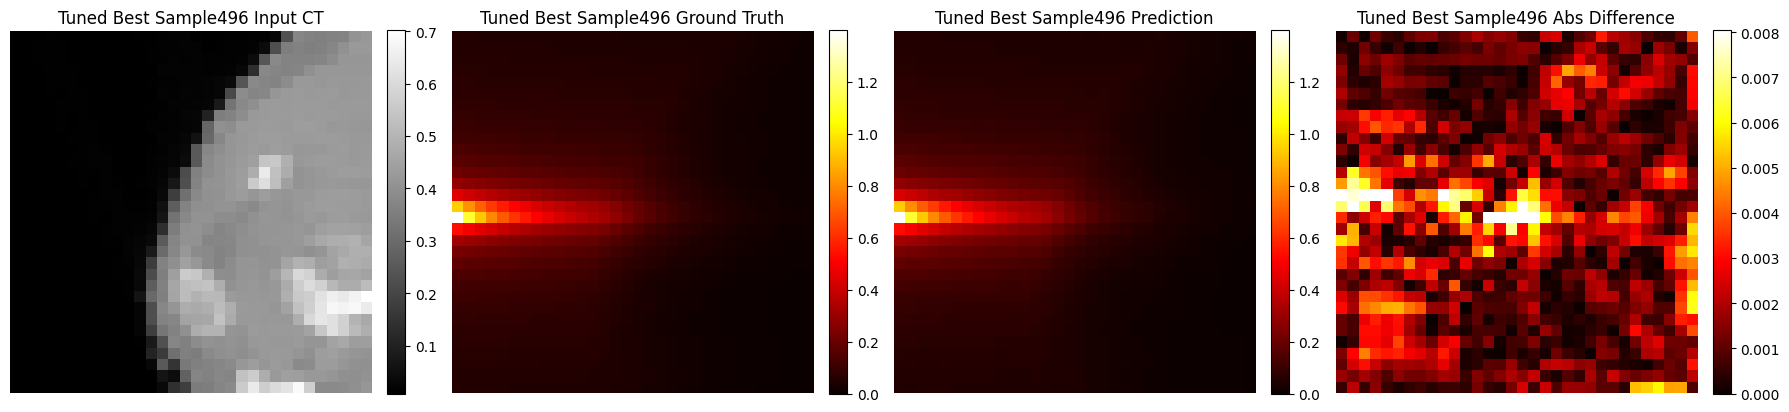

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase4_weighted_eval/tuned_vs_weighted_same_cases/tuned/tuned_best_sample496_cross_section.png


TypeError: plot_profile_with_percentage_error() got an unexpected keyword argument 'title_main'

In [40]:
case_map = {
    "best": best_case_idx,
    "typical": typical_case_idx,
    "worst": worst_case_idx,
}

all_compare_rows = []

for tag, case_idx in case_map.items():
    print(f"\n=== Running {tag} case: sample_idx={case_idx} ===")

    # tuned model
    tuned_result = analyze_one_case(
        dataset=val_dataset_3d,
        sample_idx=case_idx,
        model=tuned_model,
        device=device,
        out_dir=TUNED_CASE_DIR,
        prefix=f"tuned_{tag}_sample{case_idx}"
    )
    tuned_result.update({
        "model": "tuned",
        "case_tag": tag,
        "sample_idx": case_idx
    })

    # weighted model
    weighted_result = analyze_one_case(
        dataset=val_dataset_3d,
        sample_idx=case_idx,
        model=weighted_model,
        device=device,
        out_dir=WEIGHTED_CASE_DIR,
        prefix=f"weighted_{tag}_sample{case_idx}"
    )
    weighted_result.update({
        "model": "weighted",
        "case_tag": tag,
        "sample_idx": case_idx
    })

    all_compare_rows.extend([tuned_result, weighted_result])

compare_cases_df = pd.DataFrame(all_compare_rows)

# 建议把列顺序整理一下，读起来更清楚
preferred_cols = [
    "model", "case_tag", "sample_idx",
    "mse", "mae", "relative_error_pct",
    "gt_max", "best_slice", "peak_y", "peak_x",
    "along_mean_pct_error", "along_max_pct_error",
    "along_valid_count", "along_total_count", "along_relevant_threshold",
    "perp_mean_pct_error", "perp_max_pct_error",
    "perp_valid_count", "perp_total_count", "perp_relevant_threshold",
]
existing_cols = [c for c in preferred_cols if c in compare_cases_df.columns]
other_cols = [c for c in compare_cases_df.columns if c not in existing_cols]
compare_cases_df = compare_cases_df[existing_cols + other_cols]

compare_cases_csv = OUT_DIR / "tuned_vs_weighted_same_cases_summary.csv"
compare_cases_df.to_csv(compare_cases_csv, index=False)

print("Saved:", compare_cases_csv)
display(compare_cases_df)

In [42]:
import inspect
print("Before rerun:", inspect.signature(plot_profile_with_percentage_error))

Before rerun: (gt_curve, pred_curve, title, xlabel, save_path, pct_mode='relative_to_curve_max', pct_threshold=0.01, eps=1e-08)


### Step 11 — Samplewise histogram

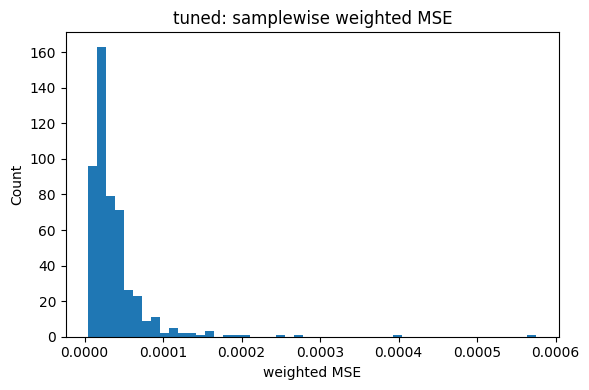

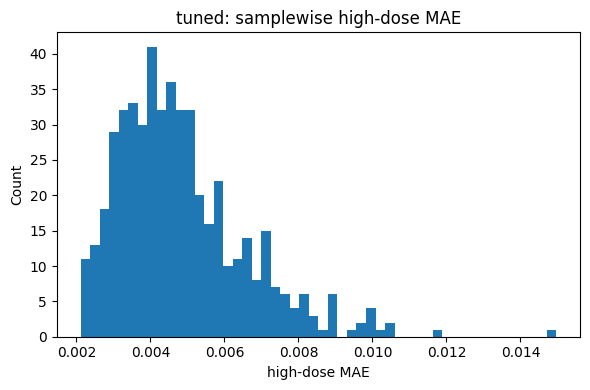

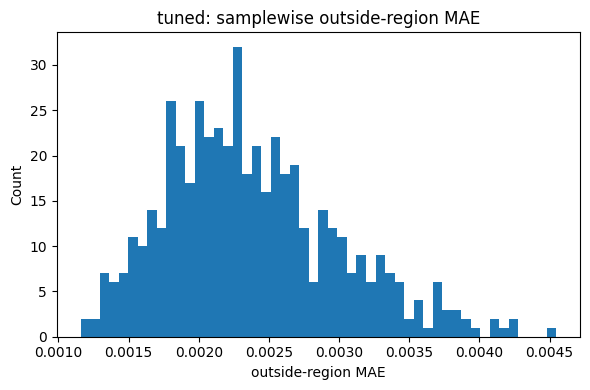

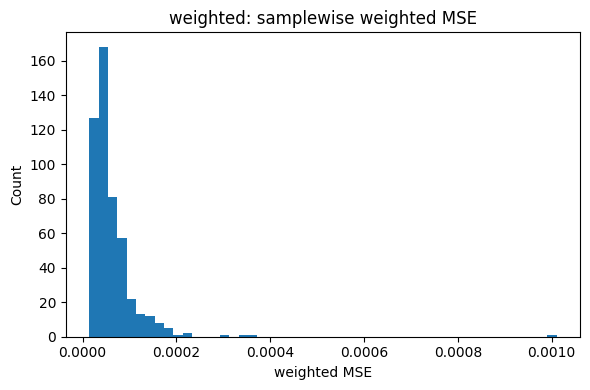

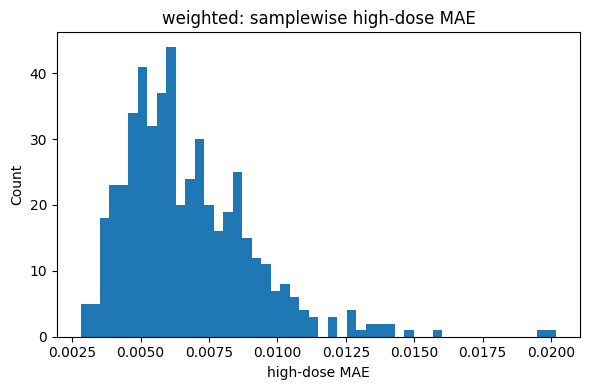

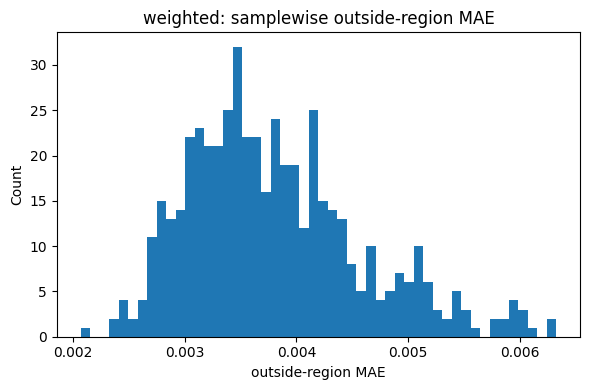

In [20]:
def save_samplewise_histograms(model_name, df, out_dir):
    sub = df[df["model"] == model_name].copy()

    plt.figure(figsize=(6,4))
    plt.hist(sub["weighted_mse"].dropna(), bins=50)
    plt.title(f"{model_name}: samplewise weighted MSE")
    plt.xlabel("weighted MSE")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(out_dir / f"{model_name}_samplewise_weighted_mse_hist.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.hist(sub["high_mae"].dropna(), bins=50)
    plt.title(f"{model_name}: samplewise high-dose MAE")
    plt.xlabel("high-dose MAE")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(out_dir / f"{model_name}_samplewise_high_mae_hist.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.hist(sub["outside_mae"].dropna(), bins=50)
    plt.title(f"{model_name}: samplewise outside-region MAE")
    plt.xlabel("outside-region MAE")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(out_dir / f"{model_name}_samplewise_outside_mae_hist.png", dpi=150, bbox_inches="tight")
    plt.show()

save_samplewise_histograms("tuned", comparison_df, OUT_DIR)
save_samplewise_histograms("weighted", comparison_df, OUT_DIR)